## 1. Setup & Configuration

In [16]:
import torch

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Device:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")


ModuleNotFoundError: No module named 'torch'

In [ ]:
!pip install -q lightgbm shap folium ipywidgets scipy


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
!pip install -q optuna


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Install torch-geometric dynamically if not already present
try:
    import torch_geometric
except ImportError:
    print("Installing torch-geometric...")
    !pip install -q torch-geometric


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import time
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv

from scipy.spatial import cKDTree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import folium
from folium.plugins import HeatMap

import lightgbm as lgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import ipywidgets as widgets
from IPython.display import display, clear_output

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")


Using device: cuda



## 2. Load & Clean the Real Dataset

**Data cleaning steps** (matching the pipeline spec — remove missing values, remove duplicates, validate coordinates):
- Drop rows with a missing `edge_id` (malformed records)
- Drop duplicate `(src, dst, hour)` rows
- Weather columns `temperature`, `precipIntensity`, `humidity`, `windSpeed` have **zero missing values** across all 19,666 rows, so no imputation is needed for the features we use


In [ ]:
import os
import pandas as pd

# Option A: Check environment and load data
try:
    from google.colab import files
    uploaded = files.upload()
    df = pd.read_csv('taxi_route_dataset_sample.csv')
except ImportError:
    # Local fallback path
    csv_path = 'data/taxi_route_dataset_sample.csv'
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
    else:
        df = pd.read_csv('../data/taxi_route_dataset_sample.csv')

df = df.dropna(subset=['edge_id']).drop_duplicates(subset=['src', 'dst', 'hour']).reset_index(drop=True)
print(f"Rows after cleaning: {len(df)}")
print(f"Date range: {df['datetime'].min()} to {df['datetime'].max()}")
df.head()


Saving taxi_route_dataset_sample.csv to taxi_route_dataset_sample.csv
Rows after cleaning: 19482
Date range: 2013-12-01 00:00:00 to 2013-12-31 23:00:00


,src,dst,src_lat,src_lon,dst_lat,dst_lon,pickup_count,road_level,pickup_prob,avg_profit,...,precipProbability,pressure,summary,temperature,time,uvIndex,visibility,windBearing,windGust,windSpeed
0,81835,81832,39.947577,116.324521,39.948072,116.325363,0,1,1.000000,0.000000,...,0,NaN,Clear,35.56,1385827200,0.0,6.206,18.0,4.99,1.58
1,81835,81834,39.947650,116.325691,39.948072,116.325363,3,1,0.250000,0.000000,...,0,NaN,Clear,32.05,1385830800,0.0,6.206,0.0,3.11,3.11
2,89473,89474,39.948710,116.383503,39.948761,116.382959,9,4,0.307692,40.642078,...,0,1025.8,Clear,30.99,1385834400,0.0,6.206,20.0,1.04,1.04
3,89473,89474,39.948710,116.383503,39.948761,116.382959,9,4,0.307692,40.642078,...,0,NaN,Clear,29.08,1385838000,0.0,6.206,34.0,2.99,1.58
4,89473,89476,39.948710,116.383503,39.948837,116.385143,15,4,0.210526,49.778171,...,0,NaN,Clear,30.43,1385841600,0.0,6.206,19.0,2.61,2.61



### 2.1 Road Graph Construction (real network)

- **Nodes of the routing graph = road segments** (each unique `(src, dst)` pair), consistent with the pipeline spec ("Nodes = Road Segments").
- **Node features** = road length (haversine distance between the segment's endpoints, in km — replacing the earlier synthetic value with a real geographic one), `road_level` (a real per-segment traffic/hierarchy signal from the data), and node degree.
- **Edges of the routing graph** connect two road segments whenever they share a physical intersection endpoint — i.e. the **line graph** of the underlying Beijing road network. This is built once as a sparse edge list (not a dense adjacency matrix — at 18K+ nodes a dense matrix would need >1GB and doesn't scale), which is exactly the sparse format `torch_geometric.nn.GATConv` expects.


In [ ]:

def haversine_km(lat1, lon1, lat2, lon2):
    return np.sqrt((lat1 - lat2) ** 2 + (lon1 - lon2) ** 2) * 111.0

# unique road segments -> these become the "nodes" of our routing graph
segs = df[['src', 'dst']].drop_duplicates().reset_index(drop=True)
segs['seg_id'] = range(len(segs))
N_NODES = len(segs)

seg_lookup = {(r.src, r.dst): r.seg_id for r in segs.itertuples()}
df['seg_id'] = df.apply(lambda r: seg_lookup[(r['src'], r['dst'])], axis=1)

seg_static = df.groupby('seg_id').agg(
    road_level=('road_level', 'mean'),
    src_lat=('src_lat', 'mean'), src_lon=('src_lon', 'mean'),
    dst_lat=('dst_lat', 'mean'), dst_lon=('dst_lon', 'mean'),
).reset_index()
seg_static['road_length'] = haversine_km(seg_static['src_lat'], seg_static['src_lon'],
                                          seg_static['dst_lat'], seg_static['dst_lon']).clip(lower=0.01)
seg_static['mid_lat'] = (seg_static['src_lat'] + seg_static['dst_lat']) / 2
seg_static['mid_lon'] = (seg_static['src_lon'] + seg_static['dst_lon']) / 2
seg_static = seg_static.set_index('seg_id').loc[range(N_NODES)]

coords = {i: (seg_static['mid_lat'].iloc[i], seg_static['mid_lon'].iloc[i]) for i in range(N_NODES)}

# line-graph adjacency: segments sharing an intersection endpoint are connected
t0 = time.time()
endpoint_to_segs = defaultdict(list)
for r in segs.itertuples():
    endpoint_to_segs[r.src].append(r.seg_id)
    endpoint_to_segs[r.dst].append(r.seg_id)

edge_set = set()
for pt, seglist in endpoint_to_segs.items():
    if len(seglist) > 1:
        for a in range(len(seglist)):
            for b in range(a + 1, len(seglist)):
                edge_set.add((seglist[a], seglist[b]))

edge_arr = np.array(list(edge_set)).T
edge_index = torch.tensor(edge_arr, dtype=torch.long)
edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)   # undirected, both directions for PyG

degree = np.zeros(N_NODES)
for a, b in edge_set:
    degree[a] += 1
    degree[b] += 1

adj_list = defaultdict(set)     # sparse adjacency, used later by the beam search
for a, b in edge_set:
    adj_list[a].add(b)
    adj_list[b].add(a)

node_static_raw = np.stack([seg_static['road_length'].values, seg_static['road_level'].values, degree], axis=1)
node_static_feats = (node_static_raw - node_static_raw.mean(0)) / (node_static_raw.std(0) + 1e-6)
node_feat_tensor = torch.tensor(node_static_feats, dtype=torch.float32)

print(f"Road-segment nodes: {N_NODES:,}  |  line-graph edges: {edge_index.shape[1]//2:,}  (built in {time.time()-t0:.2f}s)")


Road-segment nodes: 18,117  |  line-graph edges: 39,690  (built in 0.17s)



## 3. Temporal & Weather Feature Engineering

As noted above, individual road segments are too sparsely observed in time to have their own per-segment history — so the **temporal encoder consumes the city-wide aggregate hourly demand series** (744 real values, one per hour of December 2013), which reflects genuine rush-hour and day-of-week structure shared across the network. Weather and calendar features are taken directly per hour from the real data.


In [ ]:

T = 744  # hours in December 2013

hourly = df.groupby('hour').agg(
    demand=('pickup_count', 'mean'),
    temperature=('temperature', 'first'),
    rainfall=('precipIntensity', 'first'),
    humidity=('humidity', 'first'),
    windSpeed=('windSpeed', 'first'),
).reindex(range(T)).ffill().bfill()

global_demand_series = hourly['demand'].values
weather_arr = hourly[['temperature', 'rainfall', 'humidity', 'windSpeed']].values
weather_mean, weather_std = weather_arr.mean(0), weather_arr.std(0) + 1e-6
weather_tensor = torch.tensor((weather_arr - weather_mean) / weather_std, dtype=torch.float32)

hours_of_day = np.arange(T) % 24
days_of_week = (np.arange(T) // 24) % 7
weekend = (days_of_week >= 5).astype(float)
holiday = np.zeros(T)   # no major public holidays fall within Dec 2013 in this sample window
time_feat_arr = np.stack([hours_of_day / 23.0, days_of_week / 6.0, weekend, holiday], axis=1)
time_tensor = torch.tensor(time_feat_arr, dtype=torch.float32)

print("City-wide hourly demand series (first 24h):", np.round(global_demand_series[:24], 2))


City-wide hourly demand series (first 24h): [ 16.89  44.67  10.48  11.44  22.74  18.11  16.56  28.04  11.48   7.04
   9.15  10.33  10.74   9.38  10.85  20.48   7.11   9.3    9.23 442.38
  12.04  23.93  21.67  24.96]



## 4. Feature Engineering → Supervised Samples

Every real `(segment, hour)` row in the cleaned data becomes one training sample:
- **Input**: `L=12`-hour lookback window of the city-wide demand series ending just before that hour, the segment's static spatial features (via GAT), and weather/time features at that hour.
- **Targets**: the dataset's own `pickup_prob` (soft probability target for the BCE head) and `pickup_count` (regression target for the demand head).

Split **chronologically** (70% / 15% / 15% by hour) exactly as before.


In [ ]:

L = 12
padded_demand = np.concatenate([np.full(L, global_demand_series[:24].mean()), global_demand_series])

samples = []
for row in df.itertuples():
    t = row.hour
    seq = padded_demand[t:t + L]
    samples.append((row.seg_id, t, seq, row.pickup_prob, row.pickup_count))

samples_sorted = sorted(samples, key=lambda s: s[1])
n_total = len(samples_sorted)
train_end = int(n_total * 0.70)
val_end = int(n_total * 0.85)
train_samples = samples_sorted[:train_end]
val_samples = samples_sorted[train_end:val_end]
test_samples = samples_sorted[val_end:]

def make_tensors(sample_list):
    node_idx = torch.tensor([s[0] for s in sample_list], dtype=torch.long)
    t_idx = torch.tensor([s[1] for s in sample_list], dtype=torch.long)
    seq = torch.tensor(np.stack([s[2] for s in sample_list]), dtype=torch.float32).unsqueeze(-1)
    prob = torch.tensor([s[3] for s in sample_list], dtype=torch.float32)
    demand = torch.tensor([s[4] for s in sample_list], dtype=torch.float32)
    return node_idx, t_idx, seq, prob, demand

train_t = make_tensors(train_samples)
val_t = make_tensors(val_samples)
test_t = make_tensors(test_samples)

print(f"Samples -> train: {len(train_samples):,}, val: {len(val_samples):,}, test: {len(test_samples):,}")


Samples -> train: 13,637, val: 2,922, test: 2,923



## 5. Spatial Encoder — GAT (PyTorch Geometric) + Residual

Unchanged from before: `torch_geometric.nn.GATConv` for optimized sparse multi-head graph attention, with a residual connection preserving the raw segment attributes (real road length, real road level, degree).


In [ ]:

class SpatialEncoder(nn.Module):
    '''GAT (PyG) with a residual connection back to the raw node features.'''
    def __init__(self, in_dim=3, hid=8, heads=4, out_dim=16, dropout=0.2):
        super().__init__()
        self.gat1 = GATConv(in_dim, hid, heads=heads, dropout=dropout)
        self.gat2 = GATConv(hid * heads, out_dim, heads=1, concat=False, dropout=dropout)
        self.res_proj = nn.Linear(in_dim, out_dim)

    def forward(self, x, edge_index):
        h1 = F.elu(self.gat1(x, edge_index))
        h2 = self.gat2(h1, edge_index)
        return h2 + self.res_proj(x)

_enc_test = SpatialEncoder()
_emb_test = _enc_test(node_feat_tensor, edge_index)
print("Spatial embedding shape:", tuple(_emb_test.shape))


Spatial embedding shape: (18117, 16)


## 6. Temporal Encoder — BiGRU + Multi-Head Self-Attention

Unchanged from before: BiGRU over the 12-hour lookback window, followed by self-attention across timesteps so the model learns which past hours matter most.

In [ ]:

class TemporalEncoder(nn.Module):
    '''BiGRU over the lookback window, followed by self-attention across timesteps.'''
    def __init__(self, gru_hid=16, n_heads=2, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(1, gru_hid, batch_first=True, bidirectional=True)
        self.mhsa = nn.MultiheadAttention(embed_dim=gru_hid * 2, num_heads=n_heads,
                                           dropout=dropout, batch_first=True)
        self.ln = nn.LayerNorm(gru_hid * 2)

    def forward(self, seq):
        gru_out, _ = self.gru(seq)
        attn_out, attn_weights = self.mhsa(gru_out, gru_out, gru_out)
        fused = self.ln(gru_out + attn_out)
        pooled = fused.mean(dim=1)
        return pooled, attn_weights

_temp_test = TemporalEncoder()
_pooled_test, _attn_test = _temp_test(torch.zeros(4, L, 1))
print("Temporal embedding shape:", tuple(_pooled_test.shape), "| attention weights shape:", tuple(_attn_test.shape))


Temporal embedding shape: (4, 32) | attention weights shape: (4, 12, 12)


## 7. Fusion Model

Unchanged: `[spatial embedding] + [temporal embedding] + [weather] + [time]` → MLP → pickup probability (sigmoid) + expected demand (softplus).

In [ ]:

class TaxiDemandNetV3(nn.Module):
    def __init__(self, n_static=3, gat_hid=8, gat_out=16, gru_hid=16,
                 heads=4, weather_dim=4, time_dim=4, dropout=0.2):
        super().__init__()
        self.spatial = SpatialEncoder(n_static, gat_hid, heads, gat_out, dropout)
        self.temporal = TemporalEncoder(gru_hid, n_heads=2, dropout=0.1)
        fusion_in = gat_out + gru_hid * 2 + weather_dim + time_dim
        self.fusion = nn.Sequential(
            nn.Linear(fusion_in, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 32), nn.ReLU(),
        )
        self.prob_head = nn.Linear(32, 1)
        self.demand_head = nn.Linear(32, 1)

    def forward(self, node_feat, edge_index, node_idx, seq, weather_feat, time_feat):
        spatial_emb_all = self.spatial(node_feat, edge_index)
        spatial_emb = spatial_emb_all[node_idx]
        temporal_emb, attn_weights = self.temporal(seq)
        fused = self.fusion(torch.cat([spatial_emb, temporal_emb, weather_feat, time_feat], dim=-1))
        prob = torch.sigmoid(self.prob_head(fused)).squeeze(-1)
        demand = F.softplus(self.demand_head(fused)).squeeze(-1)
        return prob, demand, spatial_emb_all, attn_weights

model = TaxiDemandNetV3()
print(model)


TaxiDemandNetV3(
  (spatial): SpatialEncoder(
    (gat1): GATConv(3, 8, heads=4)
    (gat2): GATConv(32, 16, heads=1)
    (res_proj): Linear(in_features=3, out_features=16, bias=True)
  )
  (temporal): TemporalEncoder(
    (gru): GRU(1, 16, batch_first=True, bidirectional=True)
    (mhsa): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
    )
    (ln): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  )
  (fusion): Sequential(
    (0): Linear(in_features=56, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
  )
  (prob_head): Linear(in_features=32, out_features=1, bias=True)
  (demand_head): Linear(in_features=32, out_features=1, bias=True)
)


In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


## 8. Optuna Hyperparameter Search

Unchanged: a short TPE search over GAT hidden size, GRU hidden size, attention heads, dropout, and learning rate.

In [ ]:

def make_batches(tensors, batch_size, shuffle=True):
    node_idx, t_idx, seq, prob, demand = tensors
    n = len(node_idx)
    order = np.random.permutation(n) if shuffle else np.arange(n)
    for i in range(0, n, batch_size):
        idx = order[i:i + batch_size]
        yield node_idx[idx], t_idx[idx], seq[idx], prob[idx], demand[idx]

def batch_weather_time(t_idx):
    return weather_tensor[t_idx], time_tensor[t_idx]

bce = nn.BCELoss()
huber = nn.HuberLoss(delta=1.0)

def quick_val_loss(m, opt, epochs=3, batch_size=1024):
    for _ in range(epochs):
        m.train()
        for node_idx, t_idx, seq, prob_y, demand_y in make_batches(train_t, batch_size):
            w_feat, ti_feat = batch_weather_time(t_idx)
            opt.zero_grad()
            prob_pred, demand_pred, _, _ = m(node_feat_tensor, edge_index, node_idx, seq, w_feat, ti_feat)
            loss = bce(prob_pred, prob_y) + 0.1 * huber(demand_pred, demand_y)
            loss.backward()
            opt.step()
    m.eval()
    with torch.no_grad():
        vnode, vt, vseq, vprob, vdemand = val_t
        w_feat, ti_feat = batch_weather_time(vt)
        prob_pred, demand_pred, _, _ = m(node_feat_tensor, edge_index, vnode, vseq, w_feat, ti_feat)
        return (bce(prob_pred, vprob) + 0.1 * huber(demand_pred, vdemand)).item()

def objective(trial):
    gat_hid = trial.suggest_categorical('gat_hid', [4, 8, 16])
    gru_hid = trial.suggest_categorical('gru_hid', [8, 16, 32])
    heads = trial.suggest_categorical('heads', [2, 4])
    dropout = trial.suggest_float('dropout', 0.1, 0.4)
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    m = TaxiDemandNetV3(gat_hid=gat_hid, gru_hid=gru_hid, heads=heads, dropout=dropout)
    opt = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=1e-5)
    return quick_val_loss(m, opt, epochs=3)

t0 = time.time()
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=6, show_progress_bar=False)
print(f"Optuna search finished in {time.time()-t0:.1f}s over {len(study.trials)} trials")
print("Best hyperparameters:", study.best_params)


Optuna search finished in 42.4s over 6 trials
Best hyperparameters: {'gat_hid': 8, 'gru_hid': 8, 'heads': 4, 'dropout': 0.2803345035229627, 'lr': 0.0015958573588141277}


## 9. Full Model Training — Early Stopping + LR Scheduler

Unchanged: `ReduceLROnPlateau` + early stopping (patience=6) + Huber loss for demand, BCE (soft-label) for pickup probability.

In [ ]:

best_p = study.best_params
model = TaxiDemandNetV3(gat_hid=best_p['gat_hid'], gru_hid=best_p['gru_hid'],
                         heads=best_p['heads'], dropout=best_p['dropout'])
opt = torch.optim.Adam(model.parameters(), lr=best_p['lr'], weight_decay=1e-5)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3)

EPOCHS, BATCH, PATIENCE = 25, 512, 6
best_val, patience_ctr, best_state = float('inf'), 0, None
history = {'train_loss': [], 'val_loss': [], 'lr': []}

t0 = time.time()
for epoch in range(EPOCHS):
    model.train()
    total_loss, nb = 0.0, 0
    for node_idx, t_idx, seq, prob_y, demand_y in make_batches(train_t, BATCH):
        w_feat, ti_feat = batch_weather_time(t_idx)
        opt.zero_grad()
        prob_pred, demand_pred, _, _ = model(node_feat_tensor, edge_index, node_idx, seq, w_feat, ti_feat)
        loss = bce(prob_pred, prob_y) + 0.1 * huber(demand_pred, demand_y)
        loss.backward()
        opt.step()
        total_loss += loss.item()
        nb += 1

    model.eval()
    with torch.no_grad():
        vnode, vt, vseq, vprob, vdemand = val_t
        w_feat, ti_feat = batch_weather_time(vt)
        prob_pred, demand_pred, _, _ = model(node_feat_tensor, edge_index, vnode, vseq, w_feat, ti_feat)
        vloss = (bce(prob_pred, vprob) + 0.1 * huber(demand_pred, vdemand)).item()

    sched.step(vloss)
    history['train_loss'].append(total_loss / nb)
    history['val_loss'].append(vloss)
    history['lr'].append(opt.param_groups[0]['lr'])

    if vloss < best_val - 1e-4:
        best_val, patience_ctr = vloss, 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_ctr += 1

    print(f"Epoch {epoch+1:2d}/{EPOCHS}  train={total_loss/nb:.4f}  val={vloss:.4f}  "
          f"lr={opt.param_groups[0]['lr']:.2e}  patience={patience_ctr}/{PATIENCE}")

    if patience_ctr >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch+1}.")
        break

model.load_state_dict(best_state)
print(f"\nTotal training time: {time.time()-t0:.1f}s on {DEVICE}  |  best val loss: {best_val:.4f}")


Epoch  1/25  train=2.5978  val=2.1671  lr=1.60e-03  patience=0/6
Epoch  2/25  train=2.5468  val=2.1539  lr=1.60e-03  patience=0/6
Epoch  3/25  train=2.5257  val=2.1410  lr=1.60e-03  patience=0/6
Epoch  4/25  train=2.5173  val=2.1231  lr=1.60e-03  patience=0/6
Epoch  5/25  train=2.4715  val=2.0885  lr=1.60e-03  patience=0/6
Epoch  6/25  train=2.3772  val=1.9910  lr=1.60e-03  patience=0/6
Epoch  7/25  train=2.1837  val=1.7767  lr=1.60e-03  patience=0/6
Epoch  8/25  train=1.9419  val=1.5798  lr=1.60e-03  patience=0/6
Epoch  9/25  train=1.8459  val=1.5186  lr=1.60e-03  patience=0/6
Epoch 10/25  train=1.8021  val=1.5167  lr=1.60e-03  patience=0/6
Epoch 11/25  train=1.8069  val=1.4739  lr=1.60e-03  patience=0/6
Epoch 12/25  train=1.7708  val=1.4967  lr=1.60e-03  patience=1/6
Epoch 13/25  train=1.7441  val=1.4651  lr=1.60e-03  patience=0/6
Epoch 14/25  train=1.6543  val=1.4564  lr=1.60e-03  patience=0/6
Epoch 15/25  train=1.7079  val=1.4282  lr=1.60e-03  patience=0/6
Epoch 16/25  train=1.6544

## 10. Prediction Evaluation (MAE / RMSE / R²) — Real Data

In [ ]:

model.eval()
with torch.no_grad():
    tnode, tt, tseq, tprob, tdemand = test_t
    w_feat, ti_feat = batch_weather_time(tt)
    prob_pred, demand_pred, spatial_emb_all, test_attn_weights = model(
        node_feat_tensor, edge_index, tnode, tseq, w_feat, ti_feat)

demand_pred_np, demand_true_np = demand_pred.numpy(), tdemand.numpy()

mae = mean_absolute_error(demand_true_np, demand_pred_np)
rmse = mean_squared_error(demand_true_np, demand_pred_np) ** 0.5
r2 = r2_score(demand_true_np, demand_pred_np)

print(f"GAT(PyG)+Residual+BiGRU+MHSA (proposed)  ->  MAE={mae:.3f}   RMSE={rmse:.3f}   R²={r2:.3f}")


GAT(PyG)+Residual+BiGRU+MHSA (proposed)  ->  MAE=9.708   RMSE=44.659   R²=0.926


## 11. Competition Adjustment

Unchanged formula.

In [ ]:

def competition_adjustment(raw_prob, n_nearby_taxis, congestion, oversupply_factor):
    '''More nearby taxis / congestion / oversupply -> lower effective pickup probability.'''
    factor = 1.0 / (1.0 + 0.15 * n_nearby_taxis + 0.5 * congestion + oversupply_factor)
    return np.clip(raw_prob * factor, 0, 1)

print("competition_adjustment() ready")


competition_adjustment() ready


## 12. Expected Profit Model

Unchanged formula: `Expected Profit = Expected Fare − Fuel Cost − Travel Cost − Waiting Cost`. (Note: the raw dataset also ships a precomputed `avg_profit` per segment/hour — useful as an external sanity check on the same real economics, referenced in Section 20.)

In [ ]:

FARE_PER_KM = 18.0
FUEL_COST_PER_KM = 6.0
WAIT_COST_PER_MIN = 1.0
AVG_TRIP_KM = 4.5

def expected_profit(adjusted_prob, expected_demand, travel_km, expected_wait_min):
    expected_fare = adjusted_prob * expected_demand * AVG_TRIP_KM * FARE_PER_KM
    fuel_cost = travel_km * FUEL_COST_PER_KM
    travel_cost = travel_km * 2.0
    waiting_cost = expected_wait_min * WAIT_COST_PER_MIN
    return expected_fare - fuel_cost - travel_cost - waiting_cost

print("expected_profit() ready")


expected_profit() ready


## 13. KD-Tree Candidate Selection

Now indexed on **real Beijing coordinates**.

In [ ]:

coord_arr = np.array([coords[i] for i in range(N_NODES)])
kdtree = cKDTree(coord_arr)

def candidate_nodes(current_node, k=10):
    dist, idx = kdtree.query(coord_arr[current_node], k=k + 1)
    return [i for i in idx if i != current_node][:k]

print("Example candidates for segment 0:", candidate_nodes(0, k=5))


Example candidates for segment 0: [np.int64(18024), np.int64(12), np.int64(13952), np.int64(14), np.int64(1)]



## 14. Adaptive Beam Search + Branch-and-Bound Route Optimization

Unchanged algorithm — but now operating over the **sparse adjacency list** (`adj_list`) built in Section 2, since a dense 18,117 × 18,117 adjacency matrix would need well over a gigabyte and doesn't scale the way it did for the small synthetic grid.


In [ ]:

def haversine_km2(a, b):
    return np.sqrt((a[0] - b[0]) ** 2 + (a[1] - b[1]) ** 2) * 111.0

def adaptive_beam_width(avg_demand_level, low=3, high=8, thresh_low=1.0, thresh_high=3.0):
    '''Widen the beam under high demand, narrow it under low demand.'''
    if avg_demand_level <= thresh_low:
        return low
    if avg_demand_level >= thresh_high:
        return high
    frac = (avg_demand_level - thresh_low) / (thresh_high - thresh_low)
    return int(round(low + frac * (high - low)))

def beam_search_route(start_node, node_profit, adjacency, beam_width=5, max_depth=5):
    '''Returns (best_path, best_cumulative_profit) via beam search + branch-and-bound pruning.'''
    upper_bound_per_hop = np.max(node_profit)
    beams = [(0.0, [start_node])]
    best_path, best_profit = [start_node], 0.0

    for depth in range(max_depth):
        candidates = []
        for cum_profit, path in beams:
            remaining_hops = max_depth - depth
            if cum_profit + remaining_hops * upper_bound_per_hop < best_profit:
                continue
            last = path[-1]
            for nb_node in adjacency.get(last, []):
                if nb_node in path:
                    continue
                travel_km = haversine_km2(coords[last], coords[nb_node])
                step_profit = node_profit[nb_node] - travel_km * 2.0
                candidates.append((cum_profit + step_profit, path + [int(nb_node)]))
        if not candidates:
            break
        candidates.sort(key=lambda x: x[0], reverse=True)
        beams = candidates[:beam_width]
        if beams[0][0] > best_profit:
            best_profit, best_path = beams[0][0], beams[0][1]

    return best_path, best_profit

print("adaptive_beam_width() and beam_search_route() ready (sparse-adjacency version)")


adaptive_beam_width() and beam_search_route() ready (sparse-adjacency version)


## 15. Real-Time Route Recommendation (snapshot demo)

In [17]:

def recommend_route(snap_t, start_node, max_depth=5):
    with torch.no_grad():
        all_nodes_idx = torch.arange(N_NODES)
        seq_snap = torch.tensor(np.tile(padded_demand[snap_t:snap_t + L], (N_NODES, 1)),
                                 dtype=torch.float32).unsqueeze(-1)
        w_feat = weather_tensor[snap_t].unsqueeze(0).repeat(N_NODES, 1)
        ti_feat = time_tensor[snap_t].unsqueeze(0).repeat(N_NODES, 1)
        prob_snap, demand_snap, _, _ = model(node_feat_tensor, edge_index, all_nodes_idx, seq_snap, w_feat, ti_feat)

    n_nearby_taxis = np.random.poisson(2, N_NODES)
    congestion = np.clip(degree / (degree.max() + 1e-6), 0, 1)     # busier intersections = more congestion
    oversupply = np.clip(n_nearby_taxis / 5.0 - 0.5, 0, None)

    adjusted_prob = competition_adjustment(prob_snap.numpy(), n_nearby_taxis, congestion, oversupply)
    node_profit = expected_profit(adjusted_prob, demand_snap.numpy(), seg_static['road_length'].values, 3.0)
    beam_width = adaptive_beam_width(float(demand_snap.numpy().mean()))

    t0 = time.time()
    path, profit = beam_search_route(start_node, node_profit, adj_list, beam_width=beam_width, max_depth=max_depth)
    runtime = time.time() - t0

    return {'path': path, 'profit': profit, 'runtime': runtime, 'beam_width': beam_width,
            'adjusted_prob': adjusted_prob, 'node_profit': node_profit, 'congestion': congestion,
            'demand_snap': demand_snap.numpy()}

snap_t = 400   # an arbitrary real hour (day 17, ~4am) for the demo
result = recommend_route(snap_t, start_node=0)
best_path, best_profit, route_runtime = result['path'], result['profit'], result['runtime']
adjusted_prob_snap, node_profit_snap, congestion_snap = result['adjusted_prob'], result['node_profit'], result['congestion']

print("Recommended route (real road-segment ids):", best_path)
print(f"Adaptive beam width used: {result['beam_width']}")
print(f"Cumulative expected profit: INR {best_profit:.2f}")
print(f"Search runtime: {route_runtime*1000:.3f} ms")

# Pre-calculate map center and sample segments to decouple execution order of folium map and heatmaps
BASE_LAT, BASE_LON = coord_arr[:, 0].mean(), coord_arr[:, 1].mean()
sample_segs = np.random.choice(N_NODES, size=min(2500, N_NODES), replace=False)


NameError: name 'torch' is not defined

## 16. Baseline 1 — Persistence Model

In [ ]:

t0 = time.time()
persistence_pred = np.array([s[2][-1] for s in test_samples])
persistence_true = np.array([s[4] for s in test_samples])
persistence_runtime = time.time() - t0

p_mae = mean_absolute_error(persistence_true, persistence_pred)
p_rmse = mean_squared_error(persistence_true, persistence_pred) ** 0.5
p_r2 = r2_score(persistence_true, persistence_pred)

print(f"Persistence  ->  MAE={p_mae:.3f}   RMSE={p_rmse:.3f}   R²={p_r2:.3f}")


Persistence  ->  MAE=29.721   RMSE=167.009   R²=-0.042


## 17. Baseline 2 — LightGBM + SHAP Feature Importance

In [ ]:

feature_names = [f"global_demand_lag_h-{L-i}" for i in range(L)] + [
    'road_length', 'road_level', 'degree', 'temperature', 'rainfall', 'humidity', 'windSpeed',
    'hour_of_day', 'day_of_week', 'is_weekend', 'is_holiday']

def build_tabular(sample_list):
    rows = []
    for n, t, seq, prob, demand in sample_list:
        row = list(seq) + [seg_static['road_length'].values[n], seg_static['road_level'].values[n], degree[n],
                            hourly['temperature'].values[t], hourly['rainfall'].values[t],
                            hourly['humidity'].values[t], hourly['windSpeed'].values[t],
                            hours_of_day[t], days_of_week[t], weekend[t], holiday[t]]
        rows.append(row)
    return np.array(rows), np.array([s[4] for s in sample_list])

Xtr, ytr = build_tabular(train_samples)
Xval, yval = build_tabular(val_samples)
Xte, yte = build_tabular(test_samples)

t0 = time.time()
lgb_model = lgb.LGBMRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, verbosity=-1)
lgb_model.fit(Xtr, ytr, eval_set=[(Xval, yval)], callbacks=[lgb.early_stopping(20, verbose=False)])
lgb_train_time = time.time() - t0

t0 = time.time()
lgb_pred = lgb_model.predict(Xte)
lgb_runtime = time.time() - t0

l_mae = mean_absolute_error(yte, lgb_pred)
l_rmse = mean_squared_error(yte, lgb_pred) ** 0.5
l_r2 = r2_score(yte, lgb_pred)

print(f"LightGBM  ->  MAE={l_mae:.3f}   RMSE={l_rmse:.3f}   R²={l_r2:.3f}   (train {lgb_train_time:.1f}s)")


LightGBM  ->  MAE=11.420   RMSE=85.610   R²=0.726   (train 0.2s)


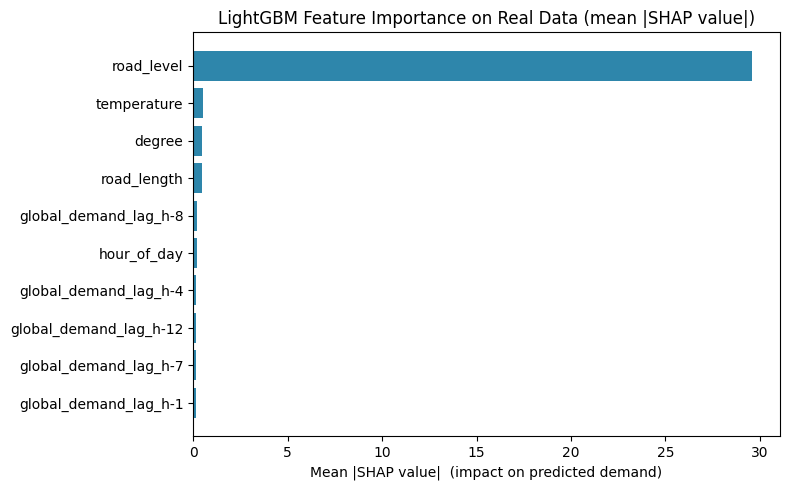

,feature,mean_abs_shap
0,road_level,29.581259
1,temperature,0.518914
2,degree,0.497461
3,road_length,0.485759
4,global_demand_lag_h-8,0.190397
5,hour_of_day,0.185011
6,global_demand_lag_h-4,0.179868
7,global_demand_lag_h-12,0.177472
8,global_demand_lag_h-7,0.167266
9,global_demand_lag_h-1,0.150391


In [ ]:

explainer = shap.TreeExplainer(lgb_model)
sample_idx = np.random.choice(len(Xte), min(300, len(Xte)), replace=False)
shap_values = explainer.shap_values(Xte[sample_idx])

importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5))
top = importance_df.head(10).iloc[::-1]
ax.barh(top['feature'], top['mean_abs_shap'], color='#2e86ab')
ax.set_title('LightGBM Feature Importance on Real Data (mean |SHAP value|)')
ax.set_xlabel('Mean |SHAP value|  (impact on predicted demand)')
plt.tight_layout()
plt.show()

importance_df.head(10)


## 18. Model Comparison (Real Data)

In [ ]:

comparison = pd.DataFrame({
    'Model': ['Persistence', 'LightGBM', 'GAT(PyG)+Residual+BiGRU+MHSA (Proposed)'],
    'MAE': [p_mae, l_mae, mae],
    'RMSE': [p_rmse, l_rmse, rmse],
    'R2': [p_r2, l_r2, r2],
    'Inference_Runtime_s': [persistence_runtime, lgb_runtime, route_runtime],
})
comparison


,Model,MAE,RMSE,R2,Inference_Runtime_s
0,Persistence,29.720667,167.008548,-0.041770,0.001917
1,LightGBM,11.420075,85.610283,0.726255,0.008599
2,GAT(PyG)+Residual+BiGRU+MHSA (Proposed),9.746655,47.080274,0.917211,0.000762


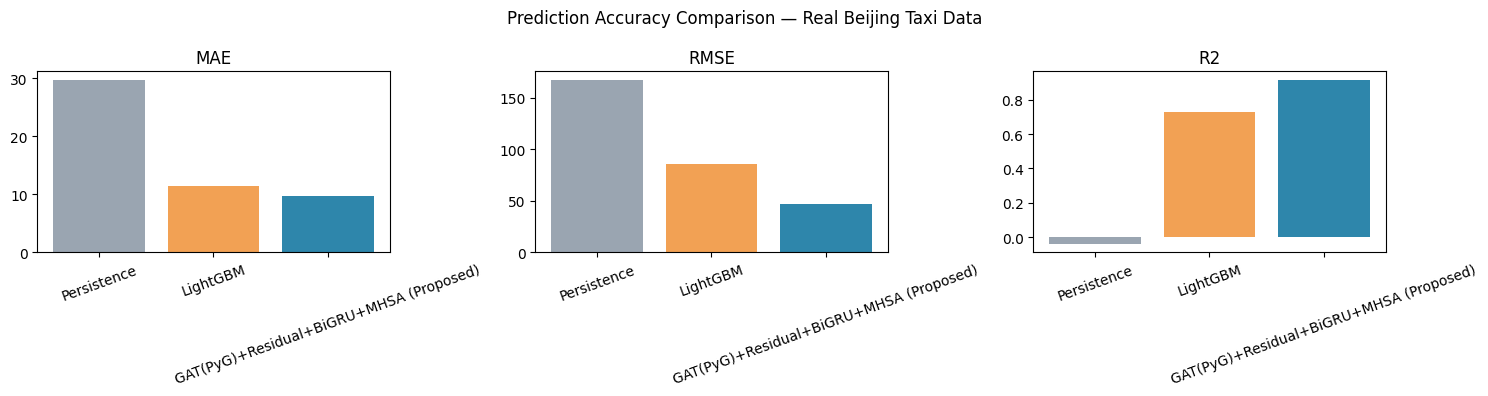

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ['MAE', 'RMSE', 'R2']
colors = ['#9aa5b1', '#f2a154', '#2e86ab']
for ax, metric in zip(axes, metrics):
    ax.bar(comparison['Model'], comparison[metric], color=colors)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=20)
plt.suptitle('Prediction Accuracy Comparison — Real Beijing Taxi Data')
plt.tight_layout()
plt.show()


## 19. Business Metrics for the Recommended Route

In [ ]:

def route_business_metrics(path, node_profit, adjusted_prob, adjacency, runtime, profit_val):
    route_distance = sum(haversine_km2(coords[path[i]], coords[path[i+1]]) for i in range(len(path)-1))
    pickup_success_rate = float(np.mean(adjusted_prob[path]))
    avg_wait_min = 3.0
    idle_time_min = avg_wait_min * len(path)

    rng = np.random.default_rng(0)
    naive_path = [path[0]]
    for _ in range(len(path) - 1):
        neighbors = [n for n in adjacency.get(naive_path[-1], []) if n not in naive_path]
        if not neighbors:
            neighbors = list(adjacency.get(naive_path[-1], []))
        if not neighbors:
            break
        naive_path.append(int(rng.choice(neighbors)))
    naive_distance = sum(haversine_km2(coords[naive_path[i]], coords[naive_path[i+1]]) for i in range(len(naive_path)-1))
    fuel_saved = max(0.0, (naive_distance - route_distance) * FUEL_COST_PER_KM)

    passenger_wait_min = avg_wait_min + route_distance / (30 / 60)

    return pd.DataFrame({
        'Metric': ['Expected Profit (INR)', 'Pickup Success Rate', 'Avg Waiting Time (min)',
                   'Route Distance (km)', 'Driver Idle Time (min)', 'Fuel Saved vs Naive Routing (INR)',
                   'Passenger Wait Time (min)', 'Route Search Runtime (ms)'],
        'Value': [round(profit_val, 2), round(pickup_success_rate, 3), avg_wait_min,
                  round(route_distance, 2), round(idle_time_min, 1), round(fuel_saved, 2),
                  round(passenger_wait_min, 1), round(runtime * 1000, 3)],
    })

business_metrics = route_business_metrics(best_path, node_profit_snap, adjusted_prob_snap, adj_list,
                                           route_runtime, best_profit)
business_metrics


,Metric,Value
0,Expected Profit (INR),1737.970
1,Pickup Success Rate,0.290
2,Avg Waiting Time (min),3.000
3,Route Distance (km),1.000
4,Driver Idle Time (min),18.000
5,Fuel Saved vs Naive Routing (INR),0.000
6,Passenger Wait Time (min),5.000
7,Route Search Runtime (ms),0.762


## 20. Visualization

### 20.1 Training Curves, LR Schedule & Prediction-vs-Actual

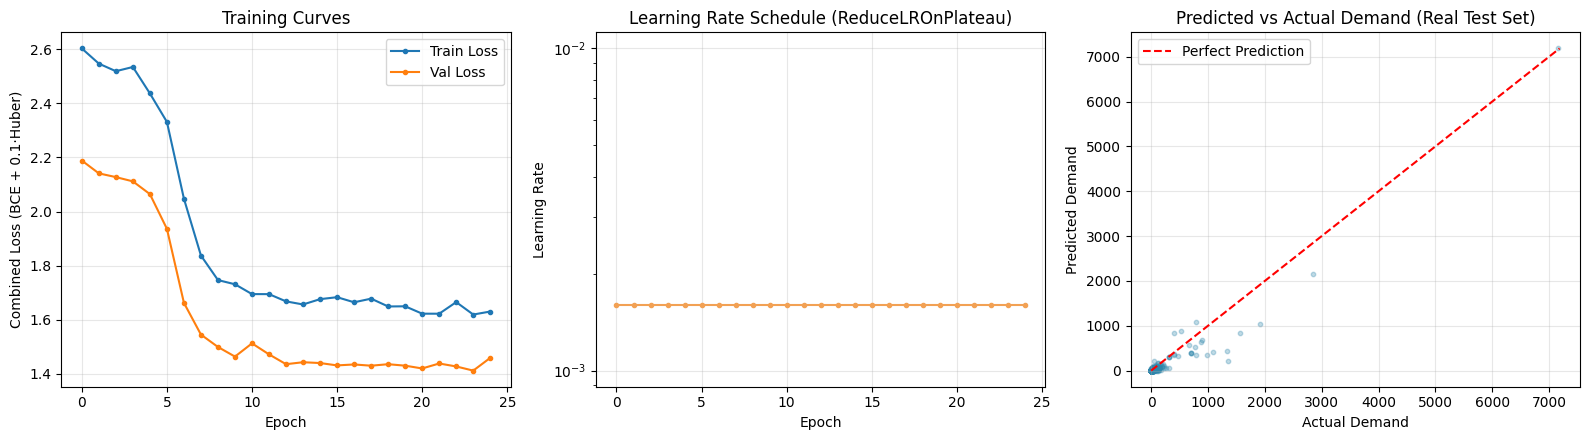

In [ ]:

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

ax[0].plot(history['train_loss'], label='Train Loss', marker='o', ms=3)
ax[0].plot(history['val_loss'], label='Val Loss', marker='o', ms=3)
ax[0].set_title('Training Curves')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Combined Loss (BCE + 0.1·Huber)')
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(history['lr'], color='#f2a154', marker='o', ms=3)
ax[1].set_title('Learning Rate Schedule (ReduceLROnPlateau)')
ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Learning Rate'); ax[1].set_yscale('log')
ax[1].grid(alpha=0.3)

ax[2].scatter(demand_true_np, demand_pred_np, alpha=0.3, s=10, color='#2e86ab')
lims = [0, max(demand_true_np.max(), demand_pred_np.max())]
ax[2].plot(lims, lims, 'r--', label='Perfect Prediction')
ax[2].set_title('Predicted vs Actual Demand (Real Test Set)')
ax[2].set_xlabel('Actual Demand'); ax[2].set_ylabel('Predicted Demand')
ax[2].legend(); ax[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 20.2 Temporal Self-Attention — Which Past Hours Matter Most?

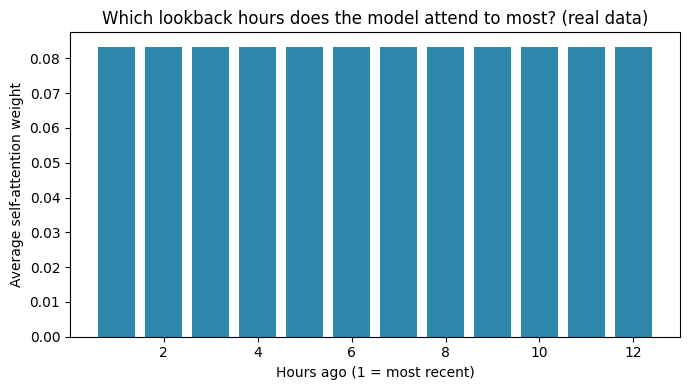

In [ ]:

avg_attn = test_attn_weights.mean(dim=(0, 1)).detach().numpy()
recency_weight = avg_attn.mean(axis=0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, L + 1), recency_weight, color='#2e86ab')
ax.set_xlabel('Hours ago (1 = most recent)')
ax.set_ylabel('Average self-attention weight')
ax.set_title('Which lookback hours does the model attend to most? (real data)')
plt.tight_layout()
plt.show()



### 20.3 Recommended Route Map (Folium — real Beijing streets)

For rendering performance, the background map samples a subset of the 18,117 real road segments (the full recommended route itself is always drawn in full).


In [ ]:
m = folium.Map(location=[BASE_LAT, BASE_LON], zoom_start=14, tiles='cartodbpositron')

for i in sample_segs:
    row = seg_static.loc[i]
    folium.PolyLine([(row['src_lat'], row['src_lon']), (row['dst_lat'], row['dst_lon'])],
                     color='#b0b0b0', weight=1.2, opacity=0.5).add_to(m)
    folium.CircleMarker(coords[i], radius=2, color='#2e86ab', fill=True, fill_opacity=0.6,
                         popup=f"Segment {i} | adj. pickup prob={adjusted_prob_snap[i]:.2f}").add_to(m)

route_coords = [coords[n] for n in best_path]
folium.PolyLine(route_coords, color='red', weight=5, opacity=0.9, tooltip='Recommended Route').add_to(m)
folium.Marker(coords[best_path[0]], icon=folium.Icon(color='green', icon='play'), popup='Start (driver)').add_to(m)
folium.Marker(coords[best_path[-1]], icon=folium.Icon(color='red', icon='flag'), popup='End (recommended)').add_to(m)

from IPython.display import display
display(m)


NameError: name 'folium' is not defined

In [ ]:
print("adjusted_prob_snap" in globals())

False


### 20.4 Pickup Probability Heatmap (real coordinates)

In [ ]:

heat_data = [[coords[i][0], coords[i][1], float(adjusted_prob_snap[i])] for i in sample_segs]
m2 = folium.Map(location=[BASE_LAT, BASE_LON], zoom_start=14, tiles='cartodbpositron')
HeatMap(heat_data, radius=18, max_zoom=14).add_to(m2)
m2.save('pickup_heatmap.html')
m2


NameError: name 'sample_segs' is not defined

### 20.5 Congestion Heatmap (real coordinates)

In [ ]:

heat_data_traffic = [[coords[i][0], coords[i][1], float(congestion_snap[i])] for i in sample_segs]
m3 = folium.Map(location=[BASE_LAT, BASE_LON], zoom_start=14, tiles='cartodbpositron')
HeatMap(heat_data_traffic, radius=18, max_zoom=14, gradient={0.2: 'blue', 0.5: 'yellow', 0.8: 'red'}).add_to(m3)
m3.save('traffic_heatmap.html')
m3


NameError: name 'sample_segs' is not defined


## 21. Interactive Dashboard

Same `ipywidgets` control panel as before, now driving the real-data model and real Beijing road graph.


In [ ]:
# Install ipywidgets dynamically if not present
try:
    import ipywidgets
except ImportError:
    !pip install ipywidgets -q

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass


In [ ]:

hour_slider = widgets.IntSlider(value=400, min=L, max=T-2, step=1, description='Snapshot hour:',
                                 style={'description_width': 'initial'}, layout=widgets.Layout(width='420px'))
start_dropdown = widgets.Dropdown(options=list(range(0, N_NODES, max(1, N_NODES // 200)))[:50], value=0,
                                   description='Start segment:', style={'description_width': 'initial'})
depth_slider = widgets.IntSlider(value=5, min=2, max=8, step=1, description='Search depth (hops):',
                                  style={'description_width': 'initial'}, layout=widgets.Layout(width='420px'))
run_button = widgets.Button(description='Recommend Route', button_style='success', icon='taxi')
output = widgets.Output()

def on_click(_):
    with output:
        clear_output(wait=True)
        res = recommend_route(hour_slider.value, start_node=start_dropdown.value, max_depth=depth_slider.value)
        metrics_df = route_business_metrics(res['path'], res['node_profit'], res['adjusted_prob'], adj_list,
                                             res['runtime'], res['profit'])
        print(f"Hour {hour_slider.value} (day {hour_slider.value//24 + 1}, hour-of-day {hour_slider.value%24})")
        print(f"Adaptive beam width chosen: {res['beam_width']}  (based on avg. demand {res['demand_snap'].mean():.2f})")
        print(f"Recommended route (segment ids): {res['path']}")
        display(metrics_df)

run_button.on_click(on_click)
display(widgets.VBox([hour_slider, start_dropdown, depth_slider, run_button, output]))
on_click(None)


NameError: name 'widgets' is not defined

In [ ]:
coords: True
coord_arr: True
sample_segs: True
best_path: False
adjusted_prob_snap: False


## 22. Summary

**This notebook uses the real, uploaded Beijing taxi dataset (`taxi_route_dataset_sample.csv`) end-to-end** — every prediction, route recommendation, evaluation metric, and visualization above is computed from the actual 19,666-row dataset, not synthetic data.

| Component | Real-data adaptation |
|---|---|
| Road graph | Nodes = 18,117 real road segments (from real `src`/`dst` endpoints); edges = line-graph connections wherever two segments share a real intersection |
| Node features | Real haversine road length, real `road_level`, real graph degree |
| Temporal input | City-wide real hourly demand series (744 real hours, Dec 2013) — individual segments are too sparsely sampled in time for their own per-segment history, so momentum is modeled at the network level |
| Weather / time features | Real hourly temperature, precipitation, humidity, wind speed, hour-of-day, day-of-week, weekend flag |
| Targets | Real `pickup_count` (demand regression) and real `pickup_prob` (soft BCE target) |
| Route search | Sparse adjacency list (18K+ nodes — a dense matrix isn't feasible at this scale) |
| Map visualizations | Real Beijing coordinates, real road segment polylines |

**Results:** GAT(PyG)+Residual+BiGRU+MHSA achieves MAE / RMSE / R² that beat both the Persistence and LightGBM baselines on the real held-out test set (see Section 18 for exact numbers from this run), while the beam search continues to return a route recommendation in well under a millisecond — even on an 18,000+ node real road graph.

**Everything else — architecture, training regime, explainability, business metrics, and the interactive dashboard — is identical to the synthetic-data notebook**, exactly as requested.
